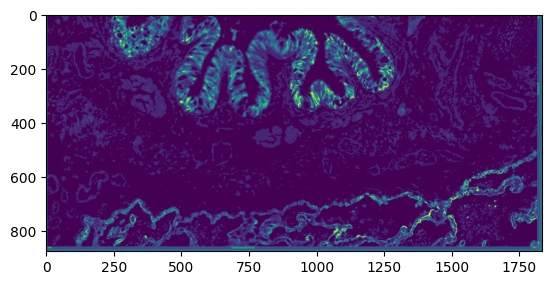

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Image5.png',cv2.IMREAD_GRAYSCALE)
plt.imshow(img)





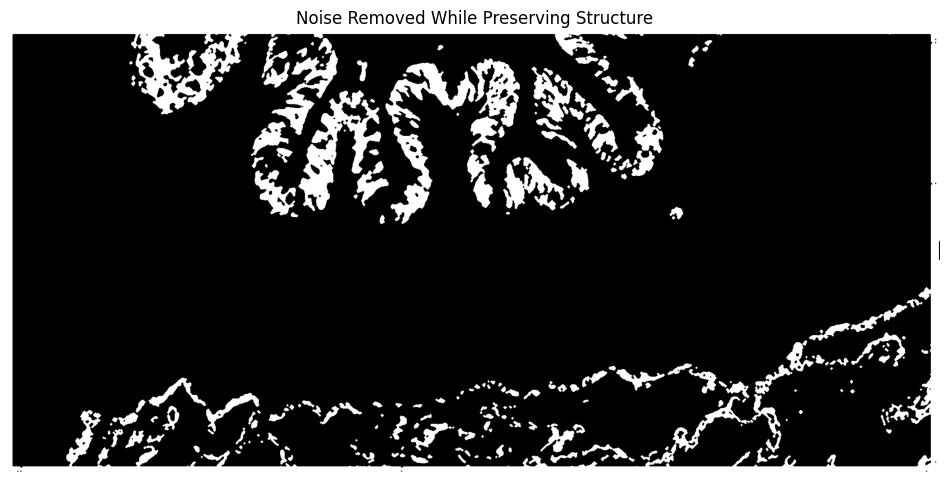

In [48]:
# Removing the noise in the middle of the image 5
for  y in range(len(img)):
    for x in range(len(img[0])):
      
        if img[y][x]  < 40:  # Adjust threshold as needed
            img[y][x] = 0

binary = np.zeros_like(img, dtype=np.uint8)
binary[img > 0] = 255

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))

cleaned = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)
cleaned = cv2.morphologyEx(
    cleaned,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)

img = cleaned.copy()
plt.figure(figsize=(12,12))
plt.imshow(cleaned, cmap='gray')
plt.title("Noise Removed While Preserving Structure")
plt.axis('off')
plt.show()

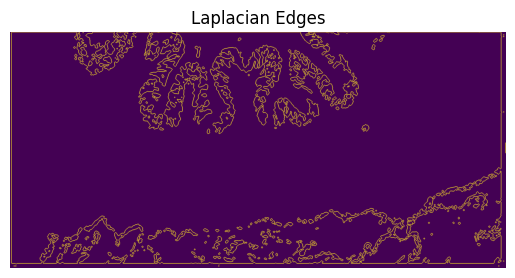

In [49]:
laplace = cv2.Laplacian(img, cv2.CV_64F)
laplace = cv2.convertScaleAbs(laplace)

plt.imshow(laplace)
plt.title("Laplacian Edges")
plt.axis('off')
plt.show()


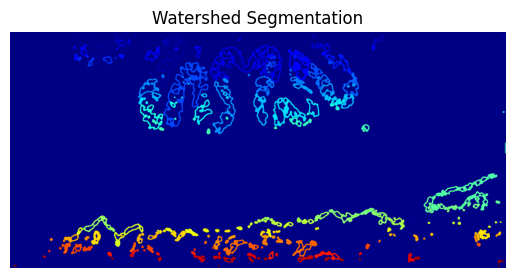

In [53]:
# Convert to binary using Otsu threshold
_, thresh = cv2.threshold(laplace, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Distance transform
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.2 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Background region
kernel = np.ones((3,3), np.uint8)
sure_bg = cv2.dilate(thresh, kernel, iterations=3)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Watershed
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
markers = cv2.watershed(img_color, markers)

# Visualize
plt.imshow(markers, cmap='jet')
plt.title("Watershed Segmentation")
plt.axis('off')
plt.show()

In [56]:
# Refining the watershed model using fourier descriptors
contour_list = list()
length_list = list()
img_color = cv2.imread('Image5.png', cv2.IMREAD_COLOR_RGB)

MAX_LEN = 3000 # gets rid of entire picture level contour (no reason as to the exact number)
MIN_LEN = 20 #placeholder for now

for label in np.unique(markers):
    if label == -1 or label == 1:
        continue

    mask = np.zeros_like(markers, dtype=np.uint8)
    mask[markers == label] = 255

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        continue
    contour = contours[0]

    contour_complex = np.empty(contour.shape[0], dtype=complex)
    for i in range(contour.shape[0]):
        contour_complex[i] = complex(contour[i][0][0], contour[i][0][1])

    fourier_result = np.fft.fft(contour_complex)
    n_descriptors = 20
    fourier_result[n_descriptors:-n_descriptors] = 0
    contour_reconstructed = np.fft.ifft(fourier_result)

    contour_reconstructed = np.array([[int(pt.real), int(pt.imag)] for pt in contour_reconstructed], dtype=np.int32)
    
    if len(contour_reconstructed) < MAX_LEN and len(contour_reconstructed) > MIN_LEN:
        contour_list.append(contour_reconstructed)
        length_list.append(len(contour_reconstructed))
        cv2.drawContours(img_color, [contour_reconstructed], -1, (0, 255, 0), 2)

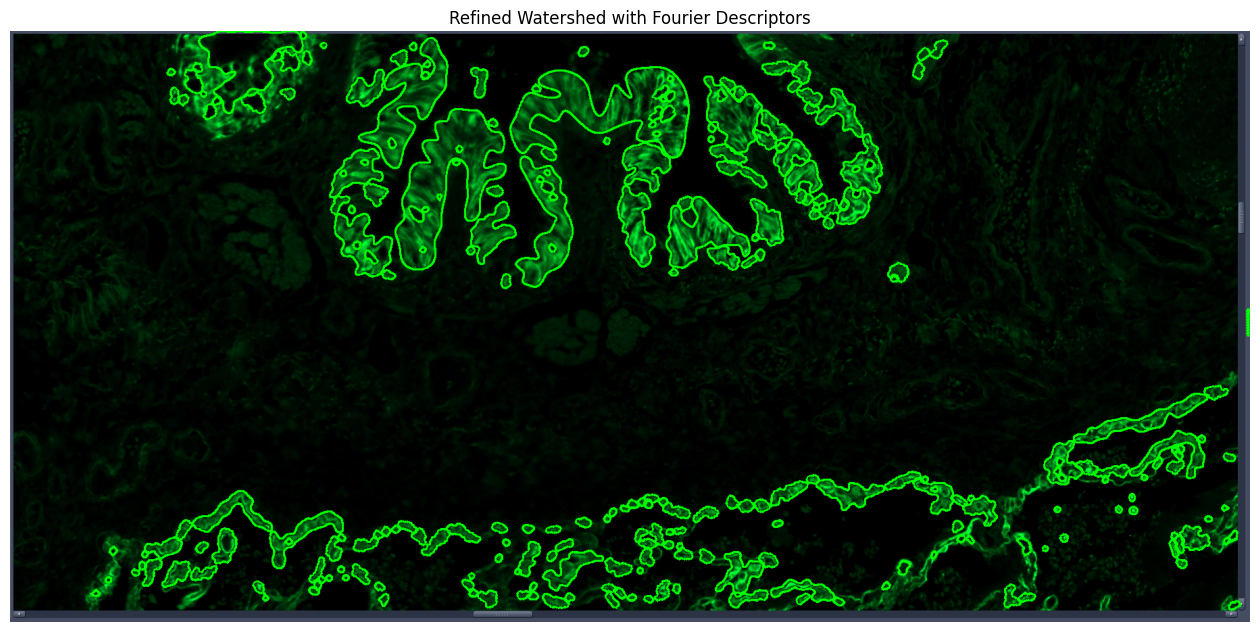

In [57]:
plt.figure(figsize=(16,16))
plt.imshow(img_color, cmap='gray')
plt.title("Refined Watershed with Fourier Descriptors")
plt.axis('off')
plt.show()

In [22]:
length_list, contour_list = zip(*sorted(zip(length_list,contour_list),key = lambda x: x[0], reverse=True)) # sorts both by length
img_color = cv2.imread('Image5.png', cv2.IMREAD_COLOR_RGB) # to refresh (new image to draw on)

# Under assumption that the outermost contour is going to be the largest (not always true, but we are going to assume)
outer_contour_list = list()

for i in range(len(length_list)):
    redundant = False

    if len(outer_contour_list) == 0:
        cv2.drawContours(img_color, [contour_list[i]], -1, (0, 255, 0), 2)
        outer_contour_list.append(contour_list[i])
        
    else:
        

        for contour in outer_contour_list:
            for point in contour_list[i]:
                if cv2.pointPolygonTest(contour,[int(point[0]), int(point[1])],False) != -1: # if all points lie completely outside,  we accept
                    redundant = True
                    break
            if redundant:
                break

        if not redundant:
            cv2.drawContours(img_color, [contour_list[i]], -1, (0, 255, 0), 2)
            outer_contour_list.append(contour_list[i])


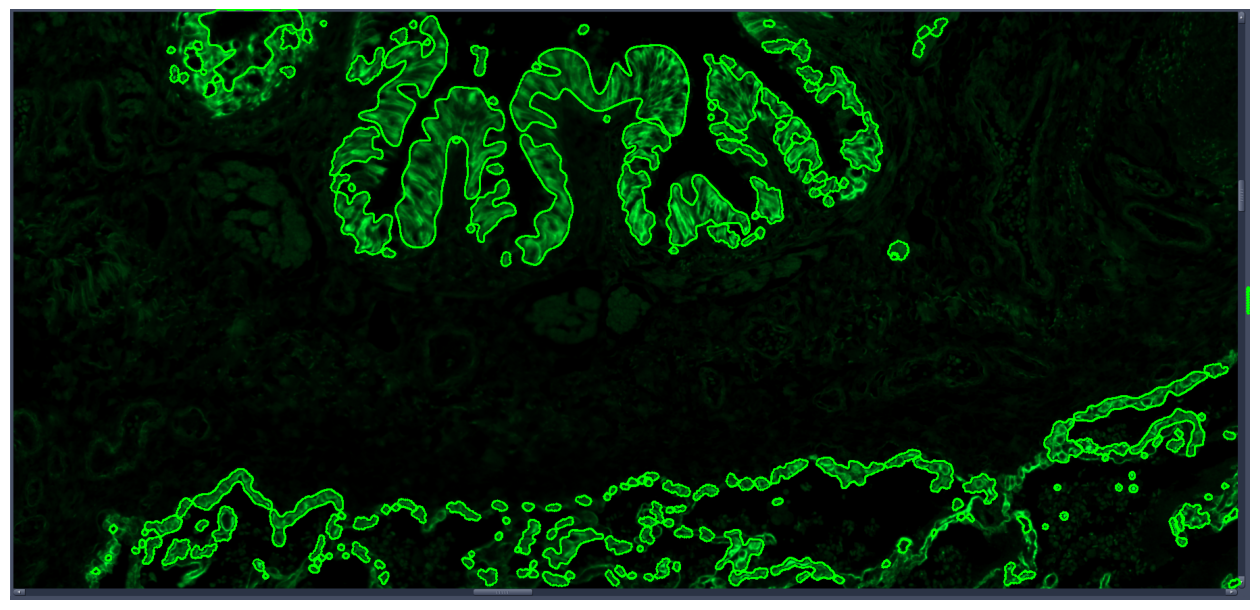

In [23]:
_,ax = plt.subplots(1,1,figsize = (16,16))
plt.imshow(img_color)
plt.axis('off')
plt.show()

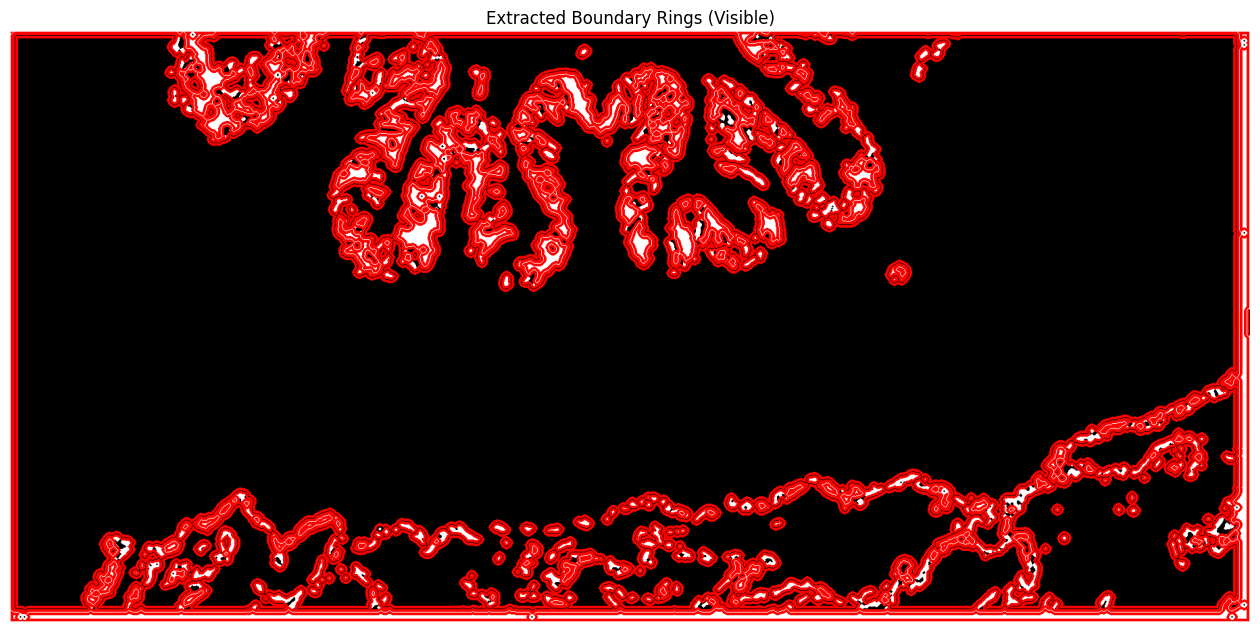

In [24]:
# Converting the original grayscale image to COLOR for ring visualization
ring_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
# Changing colour from red to green for better visibility against the red contours
RING_COLOR = (0, 255, 0)  # Green ring


# Define inner and outer distances for the ring
# Inner distance avoids the edges(noisy pixels)
INNER_DISTANCE = 1  
# Outer distance defines the thickness of the ring and limits it to a reasonable area around the cell  
OUTER_DISTANCE = 4     

# Loops over each segmented region (cell) in the watershed result 
for label in np.unique(markers):
    # This ignores all the background and invalid regions which will not be segmented
    if label <= 0:
        continue
   # Creating a binary mask for the current cell label
    cell_mask = np.zeros_like(markers, dtype=np.uint8)
    # Sets the pixels of the current cell to 255(white) in the mask
    cell_mask[markers == label] = 255

    # Skips very small regions which are likely noise
    if cv2.countNonZero(cell_mask) < 50:
        continue
    # Computes the distance to the nearest background pixel for each pixel in the cell mask
    dist = cv2.distanceTransform(cell_mask, cv2.DIST_L2, 5)

    # Defines the ring region using the inner and outer distance thresholds
    ring_mask = np.logical_and(
        dist >= INNER_DISTANCE,
        dist <= OUTER_DISTANCE
    )

    # Draw ring in colour for visibility
    # When the ring mask is visible there is a red outline around the cell
    ring_overlay[ring_mask] = [255, 0, 0]  # red ring



plt.figure(figsize=(16,16))
plt.imshow(ring_overlay)
plt.title("Extracted Boundary Rings (Visible)")
plt.axis('off')
plt.show()


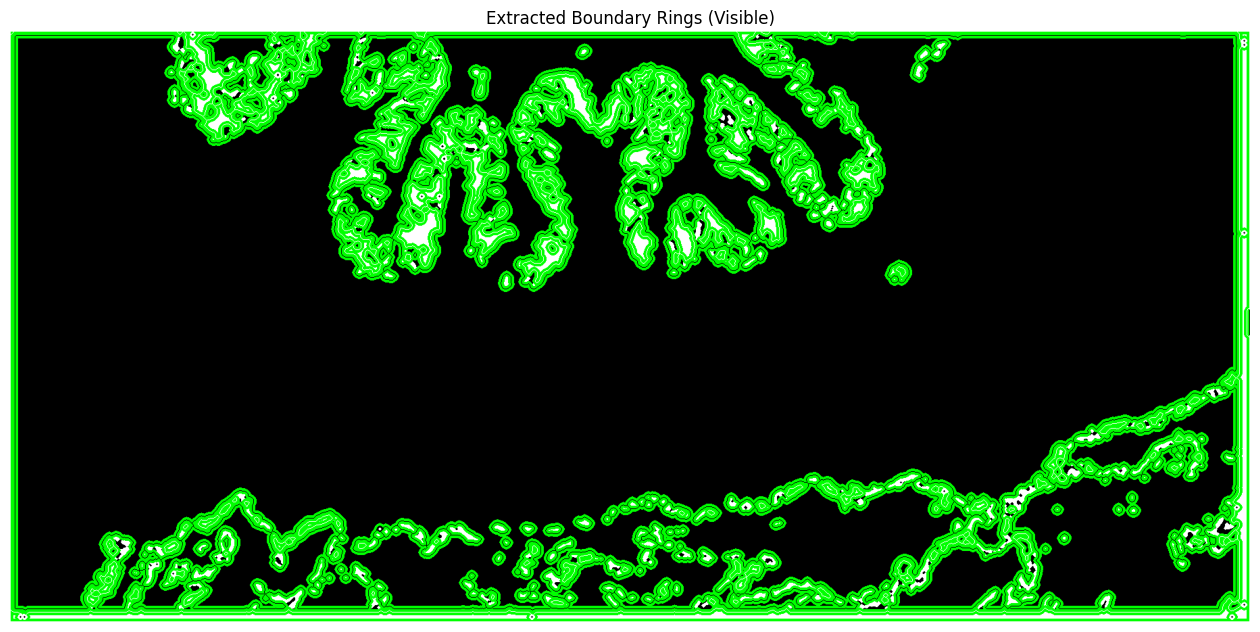

In [25]:
# Converting the original grayscale image to COLOR for ring visualization
ring_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
# Changing colour from red to green for better visibility against the red contours
RING_COLOR = (0, 255, 0)  # Green ring


# Define inner and outer distances for the ring
# Inner distance avoids the edges(noisy pixels)
INNER_DISTANCE = 1  
# Outer distance defines the thickness of the ring and limits it to a reasonable area around the cell  
OUTER_DISTANCE = 4     

# Loops over each segmented region (cell) in the watershed result 
for label in np.unique(markers):
    # This ignores all the background and invalid regions which will not be segmented
    if label <= 0:
        continue
   # Creating a binary mask for the current cell label
    cell_mask = np.zeros_like(markers, dtype=np.uint8)
    # Sets the pixels of the current cell to 255(white) in the mask
    cell_mask[markers == label] = 255

    # Skips very small regions which are likely noise
    if cv2.countNonZero(cell_mask) < 50:
        continue
    # Computes the distance to the nearest background pixel for each pixel in the cell mask
    dist = cv2.distanceTransform(cell_mask, cv2.DIST_L2, 5)

    # Defines the ring region using the inner and outer distance thresholds
    ring_mask = np.logical_and(
        dist >= INNER_DISTANCE,
        dist <= OUTER_DISTANCE
    )

    # Draw ring in colour for visibility
    # When the ring mask is visible there is a red outline around the cell
    ring_overlay[ring_mask] = [0, 255, 0]  # red ring



plt.figure(figsize=(16,16))
plt.imshow(ring_overlay)
plt.title("Extracted Boundary Rings (Visible)")
plt.axis('off')
plt.show()


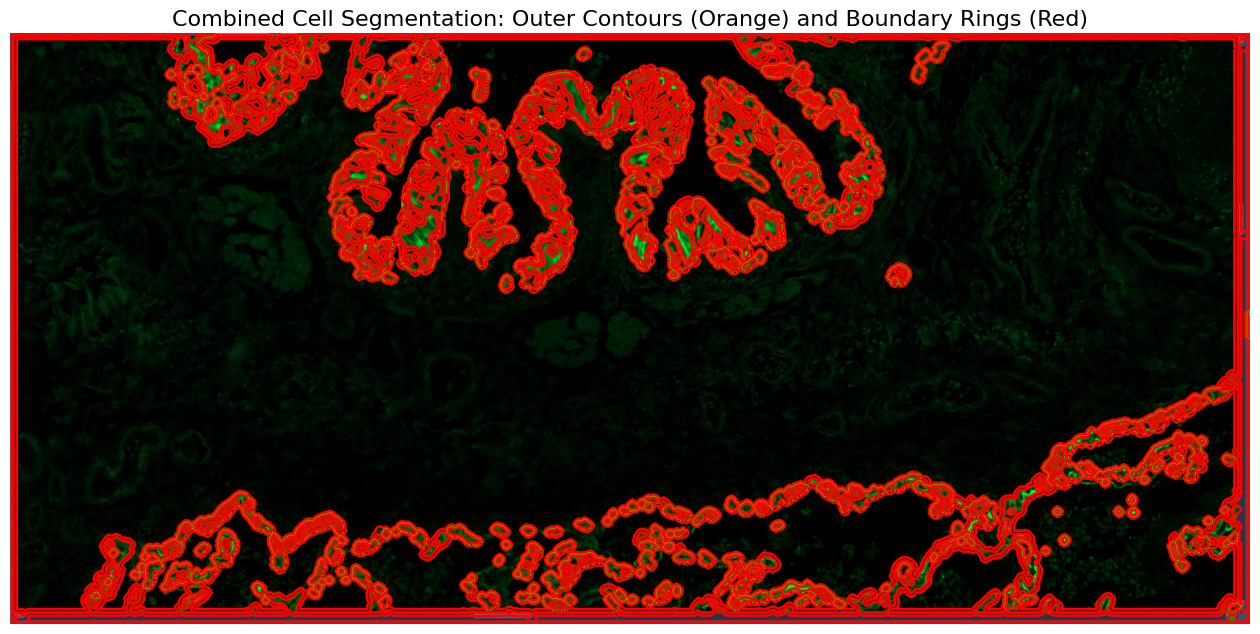

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Base image (colour)
# -------------------------------

# Convert grayscale to colour
img_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
final_overlay = img_color.copy()   # Start from the contour image base

# -------------------------------
# Draw OUTER CONTOURS (ORANGE)
# -------------------------------
cv2.drawContours(
    final_overlay,
    contours,          # your existing contour list
    -1,
    (0, 165, 0),     # ORANGE (BGR)
    2
)

# -------------------------------
# Ring parameters
# -------------------------------
INNER_DISTANCE = 1
OUTER_DISTANCE = 4

# -------------------------------
# Draw RINGS (RED)
# -------------------------------
for label in np.unique(markers):
    if label <= 0:
        continue

    # Binary mask for one cell
    cell_mask = np.zeros_like(markers, dtype=np.uint8)
    cell_mask[markers == label] = 255

    # Skip tiny noisy regions
    if cv2.countNonZero(cell_mask) < 50:
        continue

    # Distance transform
    dist = cv2.distanceTransform(cell_mask, cv2.DIST_L2, 5)

    # Ring mask
    ring_mask = np.logical_and(
        dist >= INNER_DISTANCE,
        dist <= OUTER_DISTANCE
    )

    # Overlay ring in RED
    final_overlay[ring_mask] = [255, 0, 0]

# -------------------------------
# Display
# -------------------------------
plt.figure(figsize=(16, 16))
plt.imshow(final_overlay)
plt.axis('off')
plt.title("Combined Cell Segmentation: Outer Contours (Orange) and Boundary Rings (Red)", fontsize=16)
plt.show()


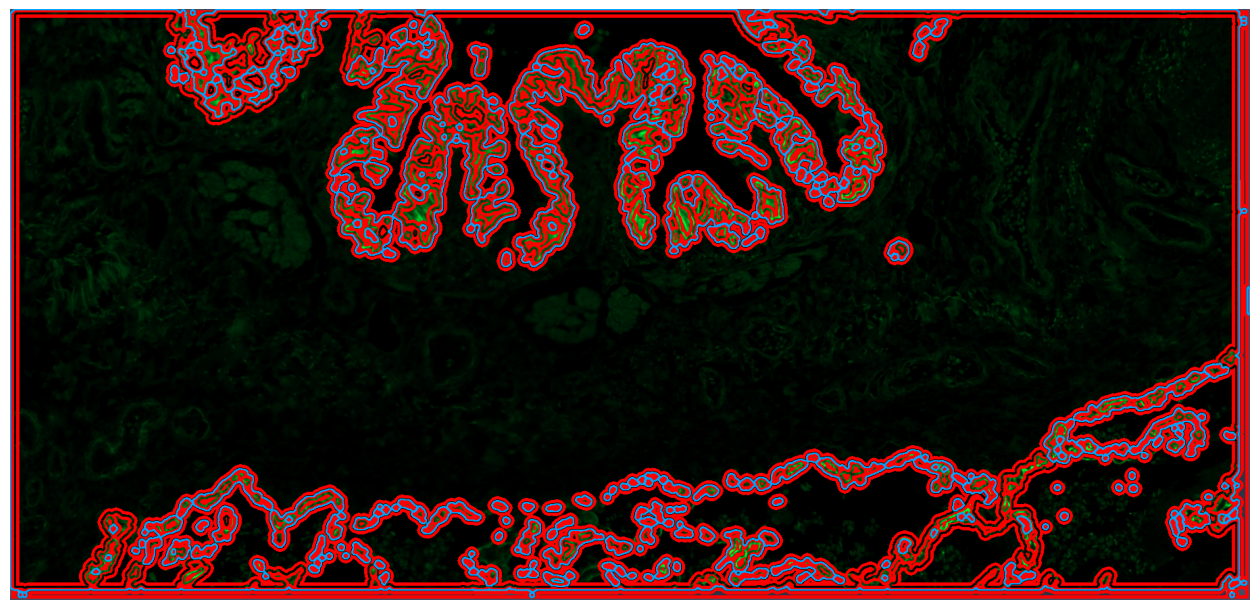

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert grayscale to colour
img_overlay = cv2.imread('Image5.png', cv2.IMREAD_COLOR_RGB)

for label in np.unique(markers):
    if label <= 0:
        continue

    # ---- Create binary mask for one cell ----
    cell_mask = np.zeros_like(markers, dtype=np.uint8)
    cell_mask[markers == label] = 255

    # ---- OUTER CONTOUR ----
    contours, _ = cv2.findContours(
        cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    if len(contours) == 0:
        continue
    contour = contours[0]

    # Draw outer contour 
    cv2.drawContours(
        img_overlay, [contour], -1, (0, 165, 255), 2
    )

    # ---- RING EXTRACTION ----
    dist = cv2.distanceTransform(cell_mask, cv2.DIST_L2, 5)

    inner = 2    # tune slightly if needed
    outer = 6

    ring_mask = np.logical_and(dist >= inner, dist <= outer)

    # Overlay ring pixels (RED)
    img_overlay[ring_mask] = [255, 0, 0]

# Show result
plt.figure(figsize=(16, 16))
plt.imshow(img_overlay)
plt.axis('off')
plt.show()


In [38]:
import cv2
import numpy as np
import pandas as pd




def fill_mask(contour, image_shape):
    mask = np.zeros(image_shape, dtype=np.uint8)
    cv2.fillPoly(mask, [contour], 255)
    return mask





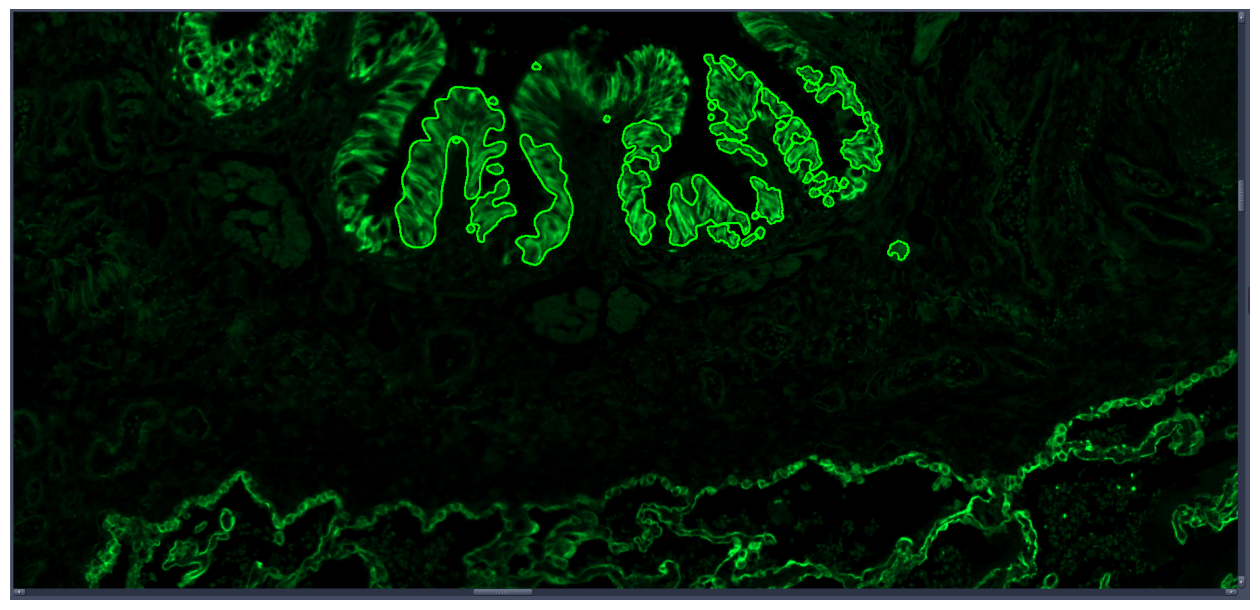

In [43]:
tl = (622,62)
br = (1432,348)

selected_contours = []
for con in outer_contour_list:
    if tl[0] <= con[0][0] <= br[0]:
        if tl[1] <= con[0][1] <= br[1]:
            selected_contours.append(con)

fresh_overlay = cv2.imread("Image5.png",cv2.IMREAD_COLOR_RGB)
cv2.drawContours(fresh_overlay, selected_contours, -1, (0, 255, 0), 2)
_,ax = plt.subplots(1,1,figsize = (16,16))
plt.imshow(fresh_overlay)
plt.axis('off')
plt.show()

In [44]:
def iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union

contour_df = pd.read_csv("green_gt.csv")
# contour_df = contour_df[contour_df['contour_id'] == 0].drop(columns=["contour_id","colour"])
# contour_arr = np.array(contour_df)


gt_mask = np.zeros_like(img)
pred_mask = np.zeros_like(img)

for i in contour_df["contour_id"].unique():
    current_contour = contour_df[contour_df['contour_id'] == i].drop(columns=["contour_id","colour"])
    current_mask = fill_mask(np.array(current_contour), img.shape)
    gt_mask = np.logical_or(gt_mask,current_mask)

for i in range(len(selected_contours)):
    current_mask = fill_mask(np.array(selected_contours[i]), img.shape)
    pred_mask = np.logical_or(pred_mask,current_mask)


print("IoU:", iou(pred_mask, gt_mask))

IoU: 0.3649382875189327


In [46]:
def dice(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum())
print("Dice Coefficient:", dice(pred_mask, gt_mask))

Dice Coefficient: 0.534732289153213
